# Breast Cancer Classification: Exploratory Analysis and Baseline

This notebook performs an initial exploration of the Breast Cancer Wisconsin Diagnostic Dataset and prepares the foundation for baseline machine learning classification.

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

In [5]:
dataset = load_breast_cancer()

X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name="target")

df = X.copy()
df["target"] = y
df["target_name"] = df["target"].map({
    0: dataset.target_names[0],
    1: dataset.target_names[1],
})

print("Dataset loaded successfully.")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Target classes: {list(dataset.target_names)}")

Dataset loaded successfully.
Number of samples: 569
Number of features: 30
Target classes: ['malignant', 'benign']


In [6]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [7]:
class_distribution = df["target_name"].value_counts()
class_distribution

benign       357
malignant    212
Name: target_name, dtype: int64

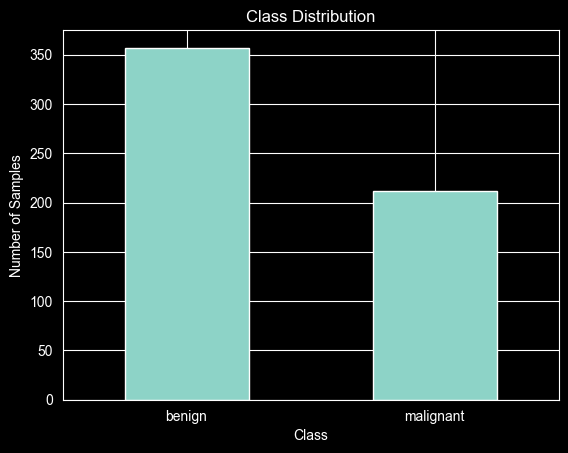

In [8]:
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

class_distribution.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.savefig(results_dir / "class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
X.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## Initial Observations

The dataset contains 569 samples and 30 numerical diagnostic features. The target labels represent malignant and benign breast cancer cases.

The class distribution is slightly imbalanced, with more benign cases than malignant cases. For this reason, evaluation should consider precision, recall, F1-score, ROC-AUC, and the confusion matrix rather than accuracy alone.